# Etapa 2. Modelado con validación segura
Partición **antes** de cualquier transformación; preprocesamiento + modelo en un `Pipeline`;
`GridSearchCV` estratificado con AUC ROC; evaluación final en el 20 % de prueba, tocado una sola vez.

In [1]:
import sys; sys.path.insert(0, "..")
import joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, accuracy_score,
                             precision_score, recall_score, f1_score)
from src.common import *

df = load_data()
X_train, X_test, y_train, y_test = split(df)       # 1) partición primero
print(X_train.shape, X_test.shape, y_train.mean().round(3), y_test.mean().round(3))

(734, 11) (184, 11) 0.553 0.554


La partición es estratificada: la prevalencia es prácticamente igual en entrenamiento y prueba, así
que las métricas de ambos conjuntos son comparables.

In [2]:
candidatos = {
    "LogisticRegression": (LogisticRegression(max_iter=2000), {"clf__C": [0.01, 0.1, 1, 10, 100]}),
    "RandomForest": (RandomForestClassifier(random_state=SEED), {"clf__n_estimators": [200, 500], "clf__max_depth": [3, 5, None], "clf__min_samples_leaf": [1, 3, 5]}),
    "GradientBoosting": (GradientBoostingClassifier(random_state=SEED), {"clf__n_estimators": [100, 200], "clf__learning_rate": [0.03, 0.1], "clf__max_depth": [2, 3]}),
}
grids = {n: train_pipeline(X_train, y_train, m, pg) for n, (m, pg) in candidatos.items()}
cv = pd.Series({n: g.best_score_ for n, g in grids.items()}).sort_values(ascending=False)
mejor = cv.index[0]
print(cv.round(4)); print("Seleccionado por AUC de validación cruzada:", mejor, grids[mejor].best_params_)

RandomForest          0.9315
GradientBoosting      0.9269
LogisticRegression    0.9227
dtype: float64
Seleccionado por AUC de validación cruzada: RandomForest {'clf__max_depth': 5, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200}


**Interpretación.** El modelo se elige **solo con la AUC de validación cruzada** sobre entrenamiento;
el conjunto de prueba no interviene en la selección. Los tres candidatos quedan dentro de ~0,01 de AUC,
así que la elección entre ellos es en la práctica una decisión de simplicidad y no de desempeño.

AUC          0.9275
Accuracy     0.8804
Precision    0.8704
Recall       0.9216
F1           0.8952
dtype: float64


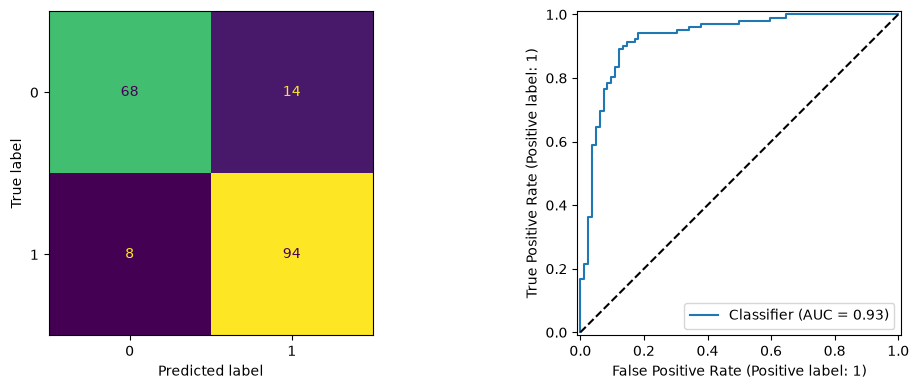

In [3]:
g = grids[mejor]
proba = g.predict_proba(X_test)[:, 1]; pred = (proba > .5).astype(int)
met = pd.Series({"AUC": roc_auc_score(y_test, proba), "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred), "Recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred)}).round(4)
print(met)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax[0], colorbar=False)
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1]); ax[1].plot([0, 1], [0, 1], "k--")
plt.tight_layout(); plt.show()

**Interpretación.** La matriz de confusión muestra el costo clínico de cada error: los falsos
negativos (pacientes enfermos clasificados como sanos) son los más graves. Con umbral 0,5 el recall
indica qué fracción de enfermos se detecta; si se priorizara no omitir casos, habría que bajar el
umbral a costa de precisión. La curva ROC queda muy por encima de la diagonal (azar).

## Verificación de ausencia de sobreajuste
AUC de entrenamiento frente a prueba y prueba de permutación de la respuesta.

In [4]:
from sklearn.model_selection import permutation_test_score, StratifiedKFold
auc_tr = roc_auc_score(y_train, g.predict_proba(X_train)[:, 1])
print(f"AUC entrenamiento {auc_tr:.4f} | CV {g.best_score_:.4f} | prueba {met['AUC']:.4f}")
sc, perm, pv = permutation_test_score(g.best_estimator_, X_train, y_train, scoring="roc_auc", n_permutations=100,
                                      cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=-1, random_state=SEED)
print(f"AUC real {sc:.4f} | AUC con respuesta permutada {perm.mean():.4f} ± {perm.std():.4f} | p = {pv:.4f}")

AUC entrenamiento 0.9608 | CV 0.9315 | prueba 0.9275


AUC real 0.9315 | AUC con respuesta permutada 0.4996 ± 0.0293 | p = 0.0099


**Interpretación.** La brecha entre entrenamiento y prueba mide el sobreajuste; la permutación
confirma que la AUC no se debe al azar: con la respuesta barajada el modelo cae a ~0,5.

## Exportación del modelo
Se reentrena el mejor pipeline con **todos** los datos de entrenamiento (ya lo está, `refit=True`) y se
guarda junto al conjunto de referencia para el monitoreo.

In [5]:
joblib.dump(g.best_estimator_, ROOT / "model.joblib")
joblib.dump(g.best_estimator_, ROOT / "app" / "model.joblib")
X_train.to_csv(ROOT / "data" / "reference.csv", index=False)
X_test.to_csv(ROOT / "data" / "current.csv", index=False)
print("modelo guardado")

modelo guardado
